In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
TEST_DIR = PROJECT_ROOT / "data" / "test"

files = sorted(TEST_DIR.glob("*.png"))

print(f"{len(files):,} images")

20,000 images


In [4]:
records = []

for path in tqdm(files):
    with Image.open(path) as img:
        w, h = img.size

        records.append({
            "filename": path.name,
            "width": w,
            "height": h,
            "aspect_ratio": w / h,
            "mode": img.mode,
        })

df = pd.DataFrame(records)

df.head()

100%|██████████| 20000/20000 [00:00<00:00, 20338.38it/s]


,filename,width,height,aspect_ratio,mode
0,test_00000.png,73,25,2.920000,RGB
1,test_00001.png,119,19,6.263158,RGB
2,test_00002.png,1584,269,5.888476,RGB
3,test_00003.png,55,12,4.583333,RGB
4,test_00004.png,145,28,5.178571,RGB


In [5]:
df.describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99])

,width,height,aspect_ratio
count,20000.000000,20000.000000,20000.000000
mean,357.603600,64.398150,6.220858
std,318.933591,59.337019,4.267151
min,25.000000,10.000000,0.720930
1%,40.000000,12.000000,1.761886
5%,61.000000,16.000000,2.319909
10%,79.000000,18.000000,2.688264
25%,129.000000,27.000000,3.503241
50%,238.000000,42.000000,4.894899
75%,479.250000,76.000000,7.518636


In [6]:
print("Modes:")
display(df["mode"].value_counts())

print("\nWidth:")
display(df["width"].describe(
    percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]
))

print("\nHeight:")
display(df["height"].describe(
    percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]
))

print("\nAspect ratio:")
display(df["aspect_ratio"].describe(
    percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]
))

Modes:


mode
RGB    20000
Name: count, dtype: int64


Width:


count    20000.000000
mean       357.603600
std        318.933591
min         25.000000
1%          40.000000
5%          61.000000
10%         79.000000
25%        129.000000
50%        238.000000
75%        479.250000
90%        858.000000
95%       1047.000000
99%       1406.000000
max       1599.000000
Name: width, dtype: float64


Height:


count    20000.000000
mean        64.398150
std         59.337019
min         10.000000
1%          12.000000
5%          16.000000
10%         18.000000
25%         27.000000
50%         42.000000
75%         76.000000
90%        149.000000
95%        195.000000
99%        289.000000
max        492.000000
Name: height, dtype: float64


Aspect ratio:


count    20000.000000
mean         6.220858
std          4.267151
min          0.720930
1%           1.761886
5%           2.319909
10%          2.688264
25%          3.503241
50%          4.894899
75%          7.518636
90%         11.457262
95%         14.447785
99%         22.609812
max         49.666667
Name: aspect_ratio, dtype: float64

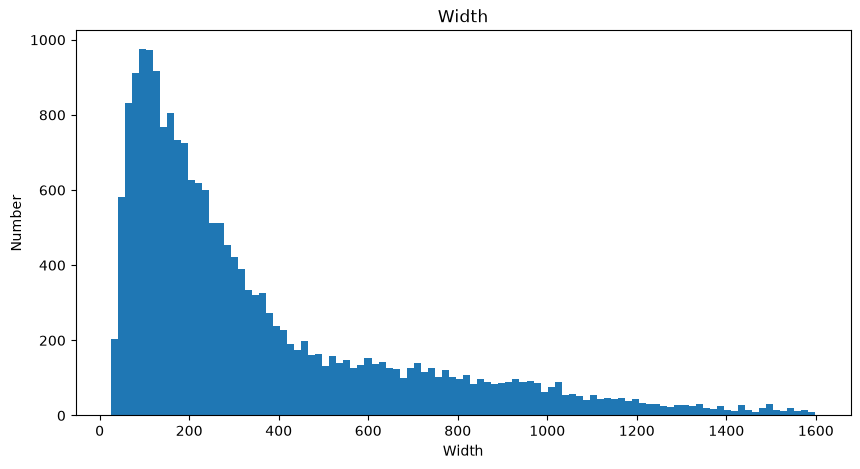

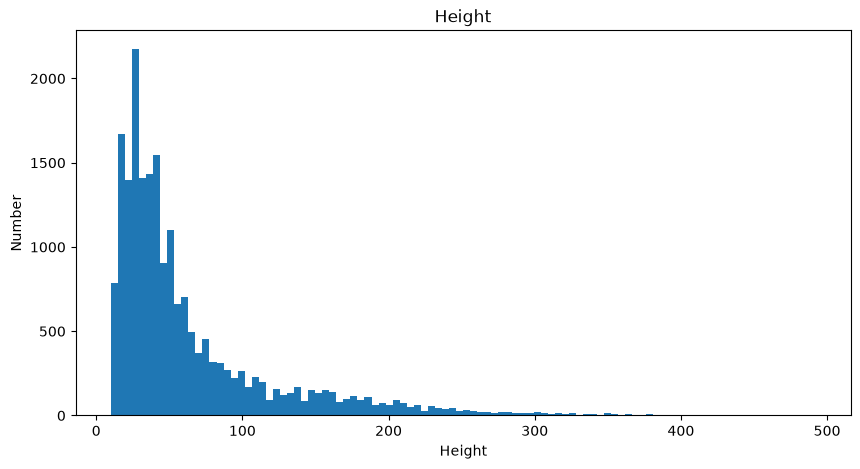

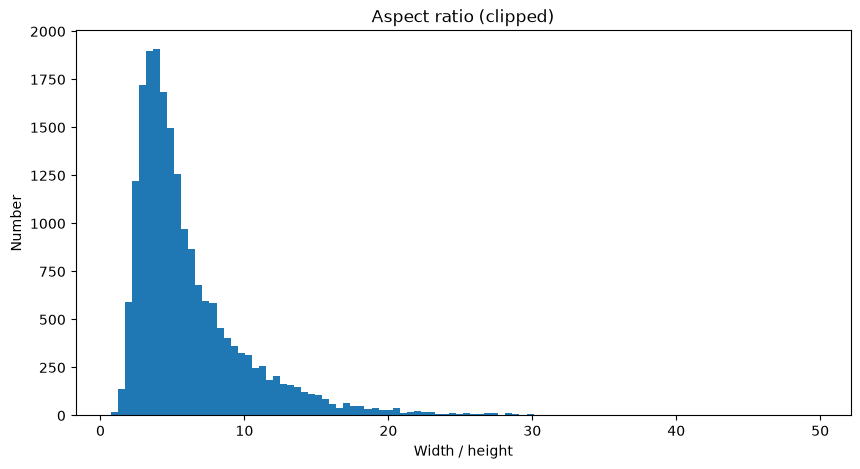

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df["width"], bins=100)
plt.xlabel("Width")
plt.ylabel("Number")
plt.title("Width")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["height"], bins=100)
plt.xlabel("Height")
plt.ylabel("Number")
plt.title("Height")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["aspect_ratio"], bins=100)
plt.xlabel("Width / height")
plt.ylabel("Number")
plt.title("Aspect ratio (clipped)")
plt.show()

In [15]:
def show_images(rows, cols=4, figsize=(16, 10)):
    rows = rows.reset_index(drop=True)
    n = len(rows)
    r = int(np.ceil(n / cols))

    fig, axes = plt.subplots(r, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i, row in rows.iterrows():
        img = Image.open(TEST_DIR / row["filename"])

        axes[i].imshow(img)
        axes[i].set_title(
            f'{row["filename"]}\n'
            f'{row["width"]}×{row["height"]}, '
            f'AR={row["aspect_ratio"]:.1f}'
        )
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

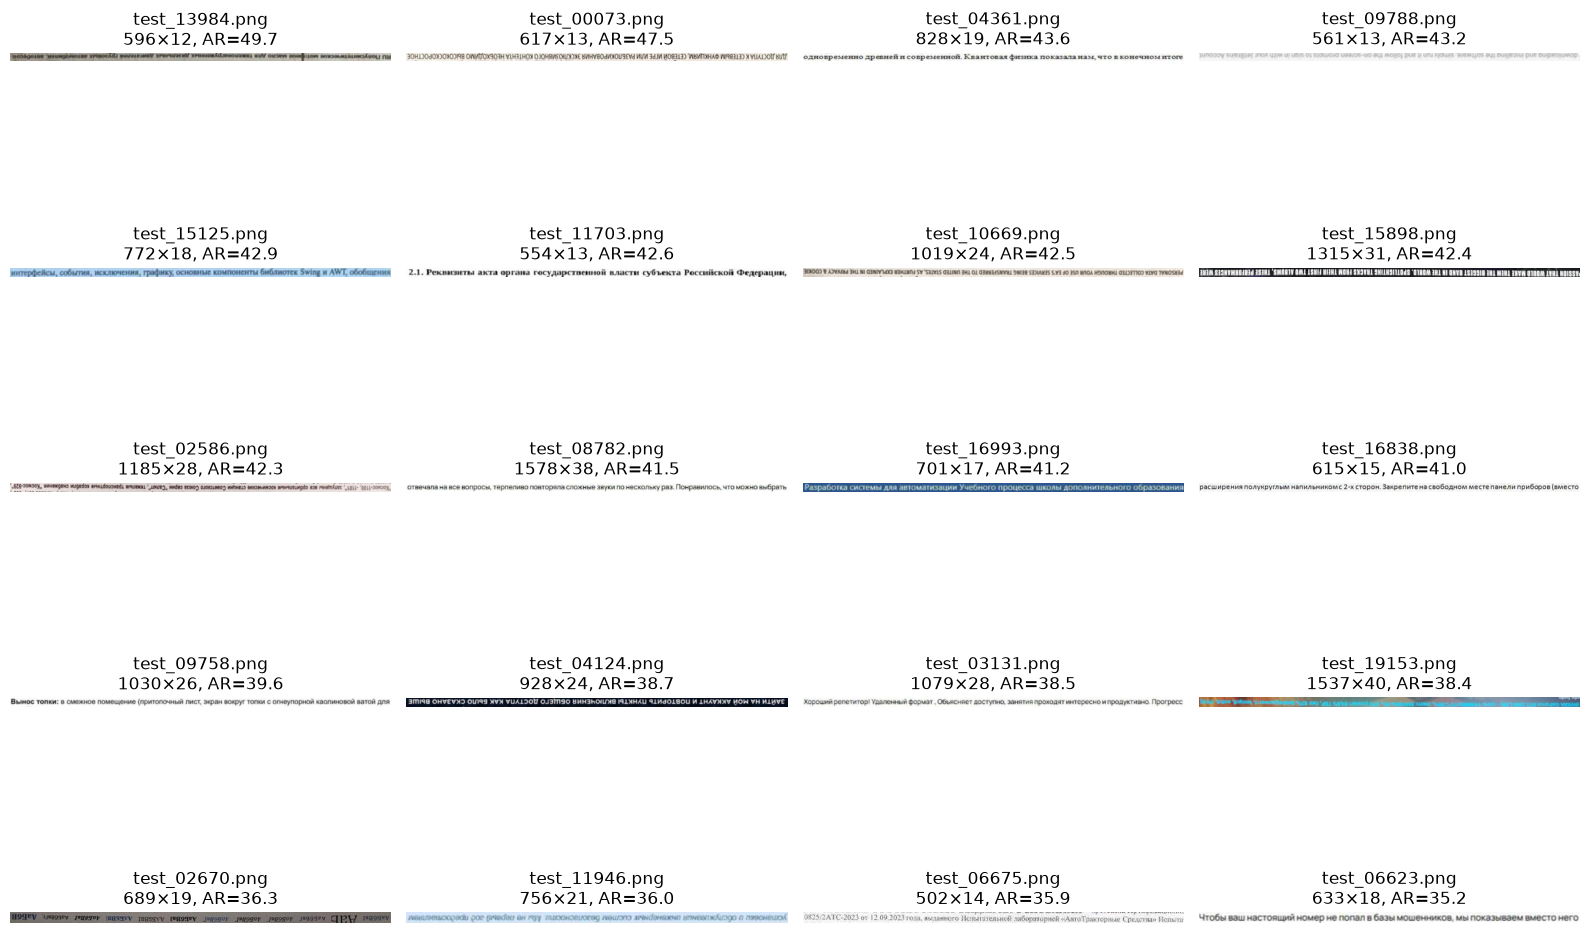

In [16]:
show_images(
    df.nlargest(20, "aspect_ratio"),
    cols=4,
    figsize=(16, 12)
)

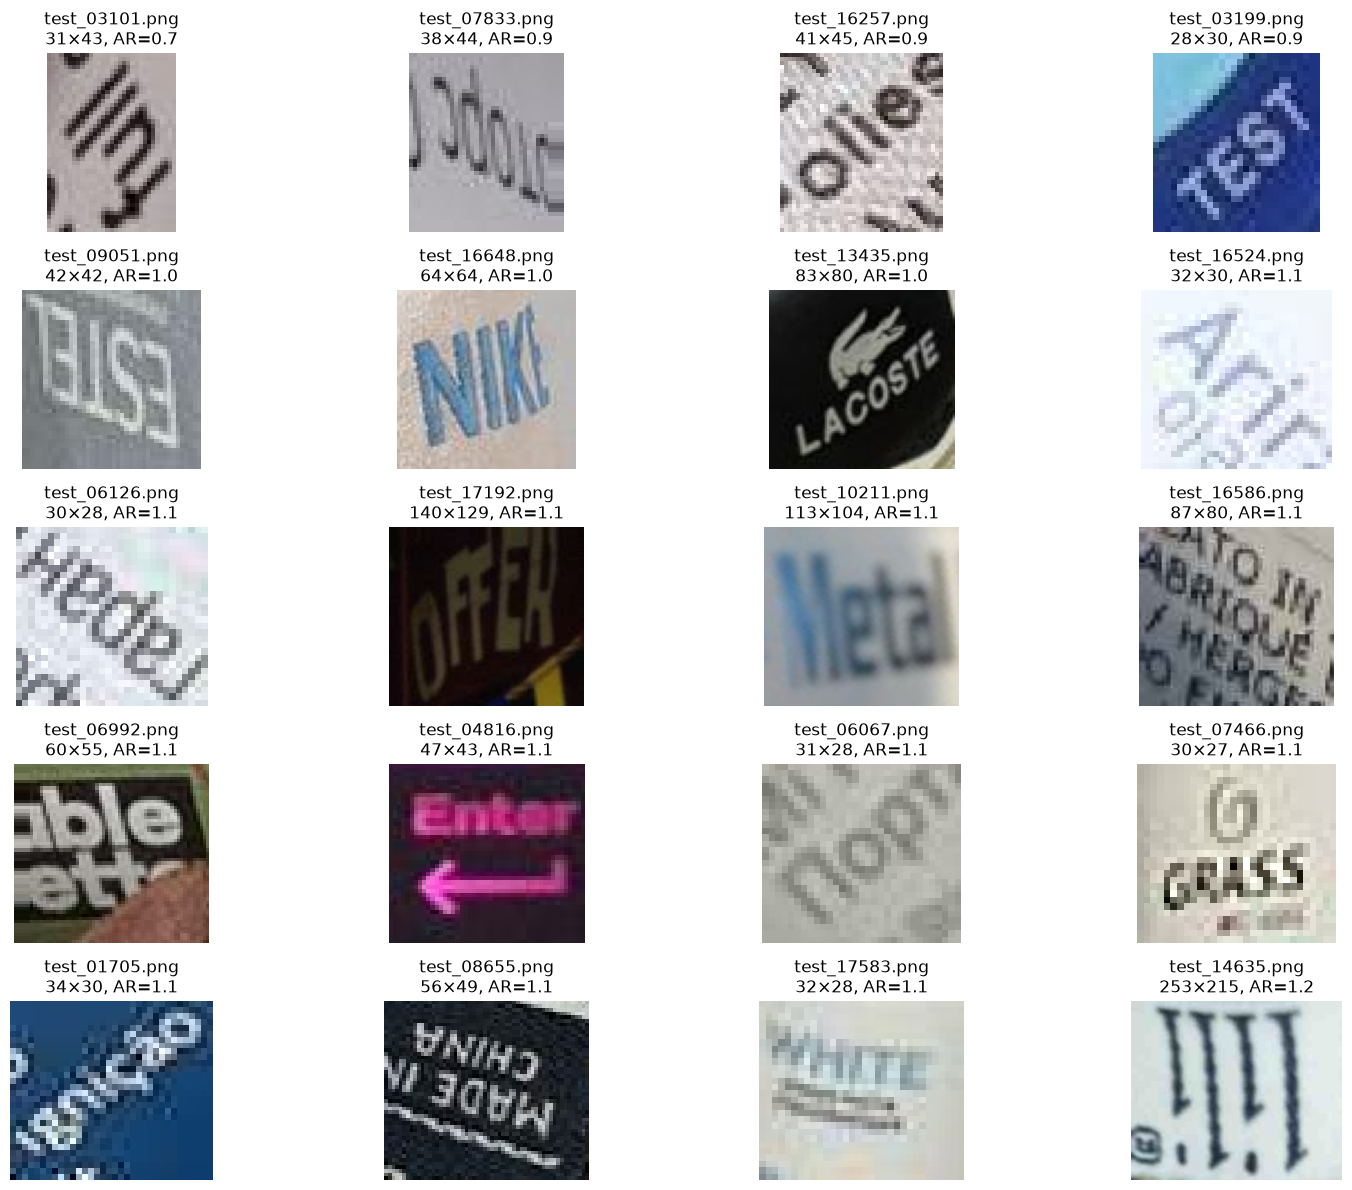

In [17]:
show_images(
    df.nsmallest(20, "aspect_ratio"),
    cols=4,
    figsize=(16, 12)
)

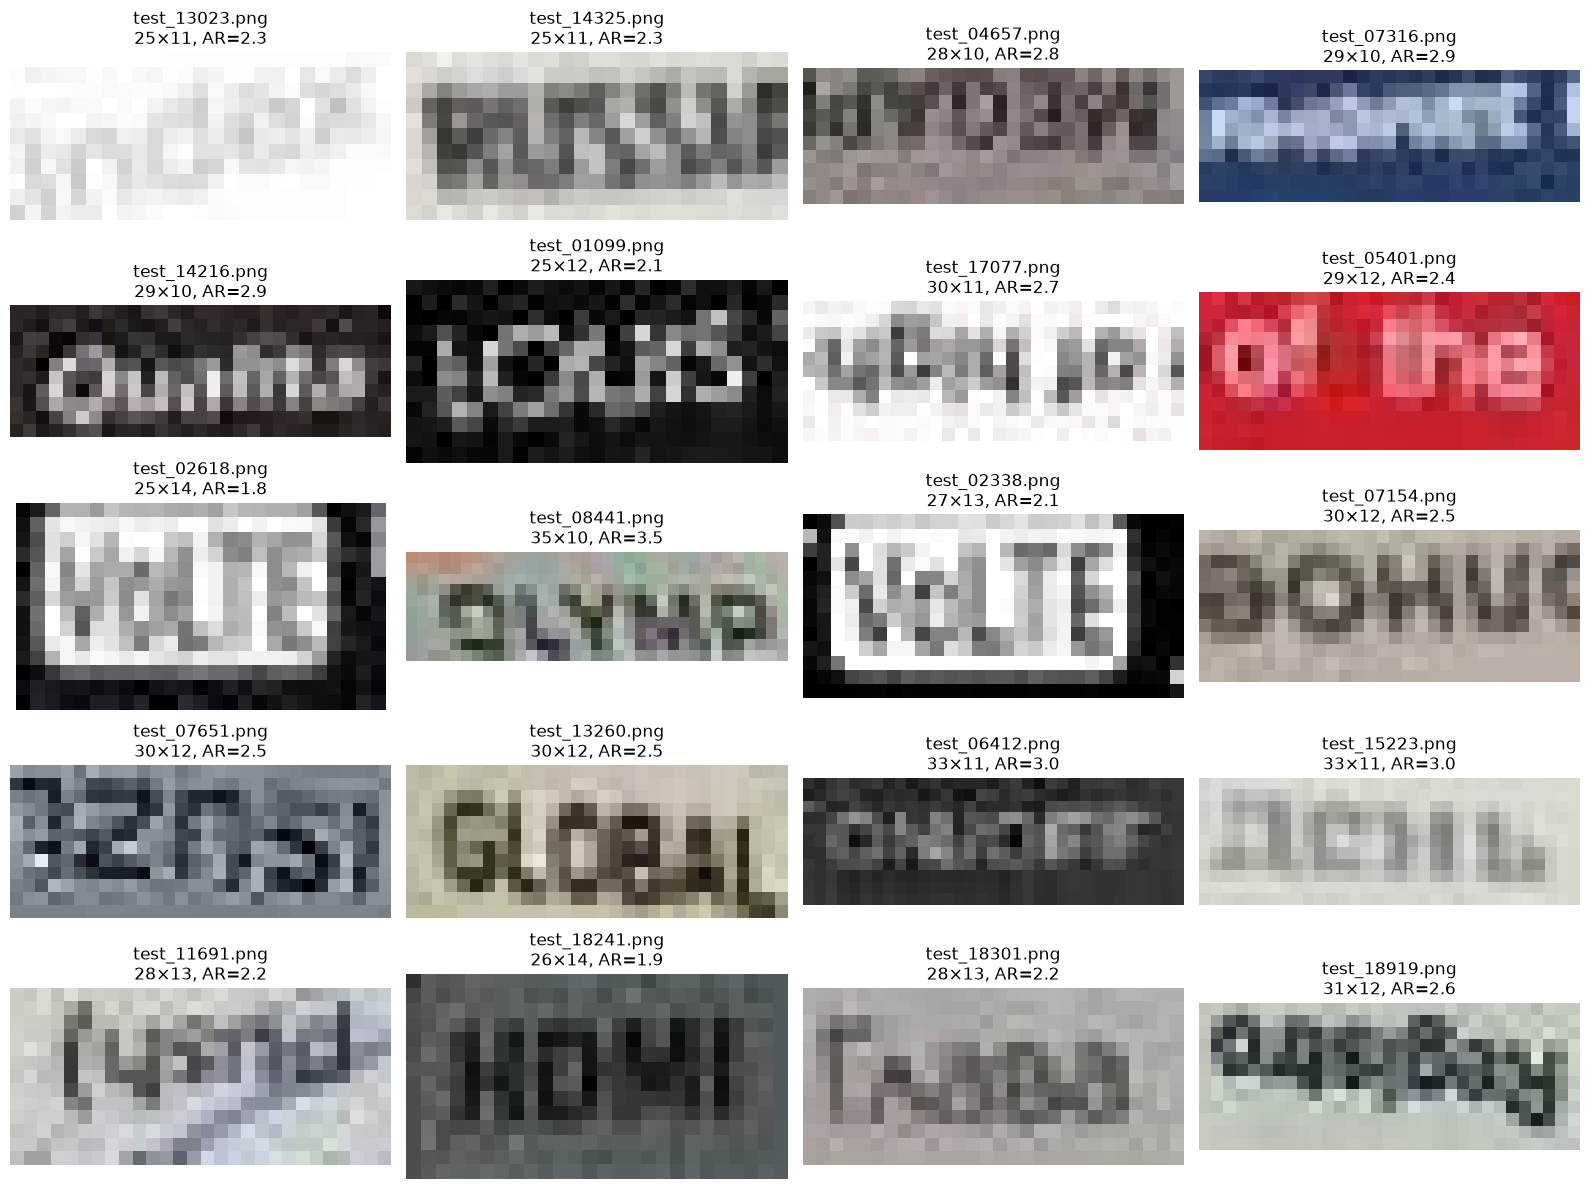

In [18]:
df["area"] = df["width"] * df["height"]

show_images(
    df.nsmallest(20, "area"),
    cols=4,
    figsize=(16, 12)
)

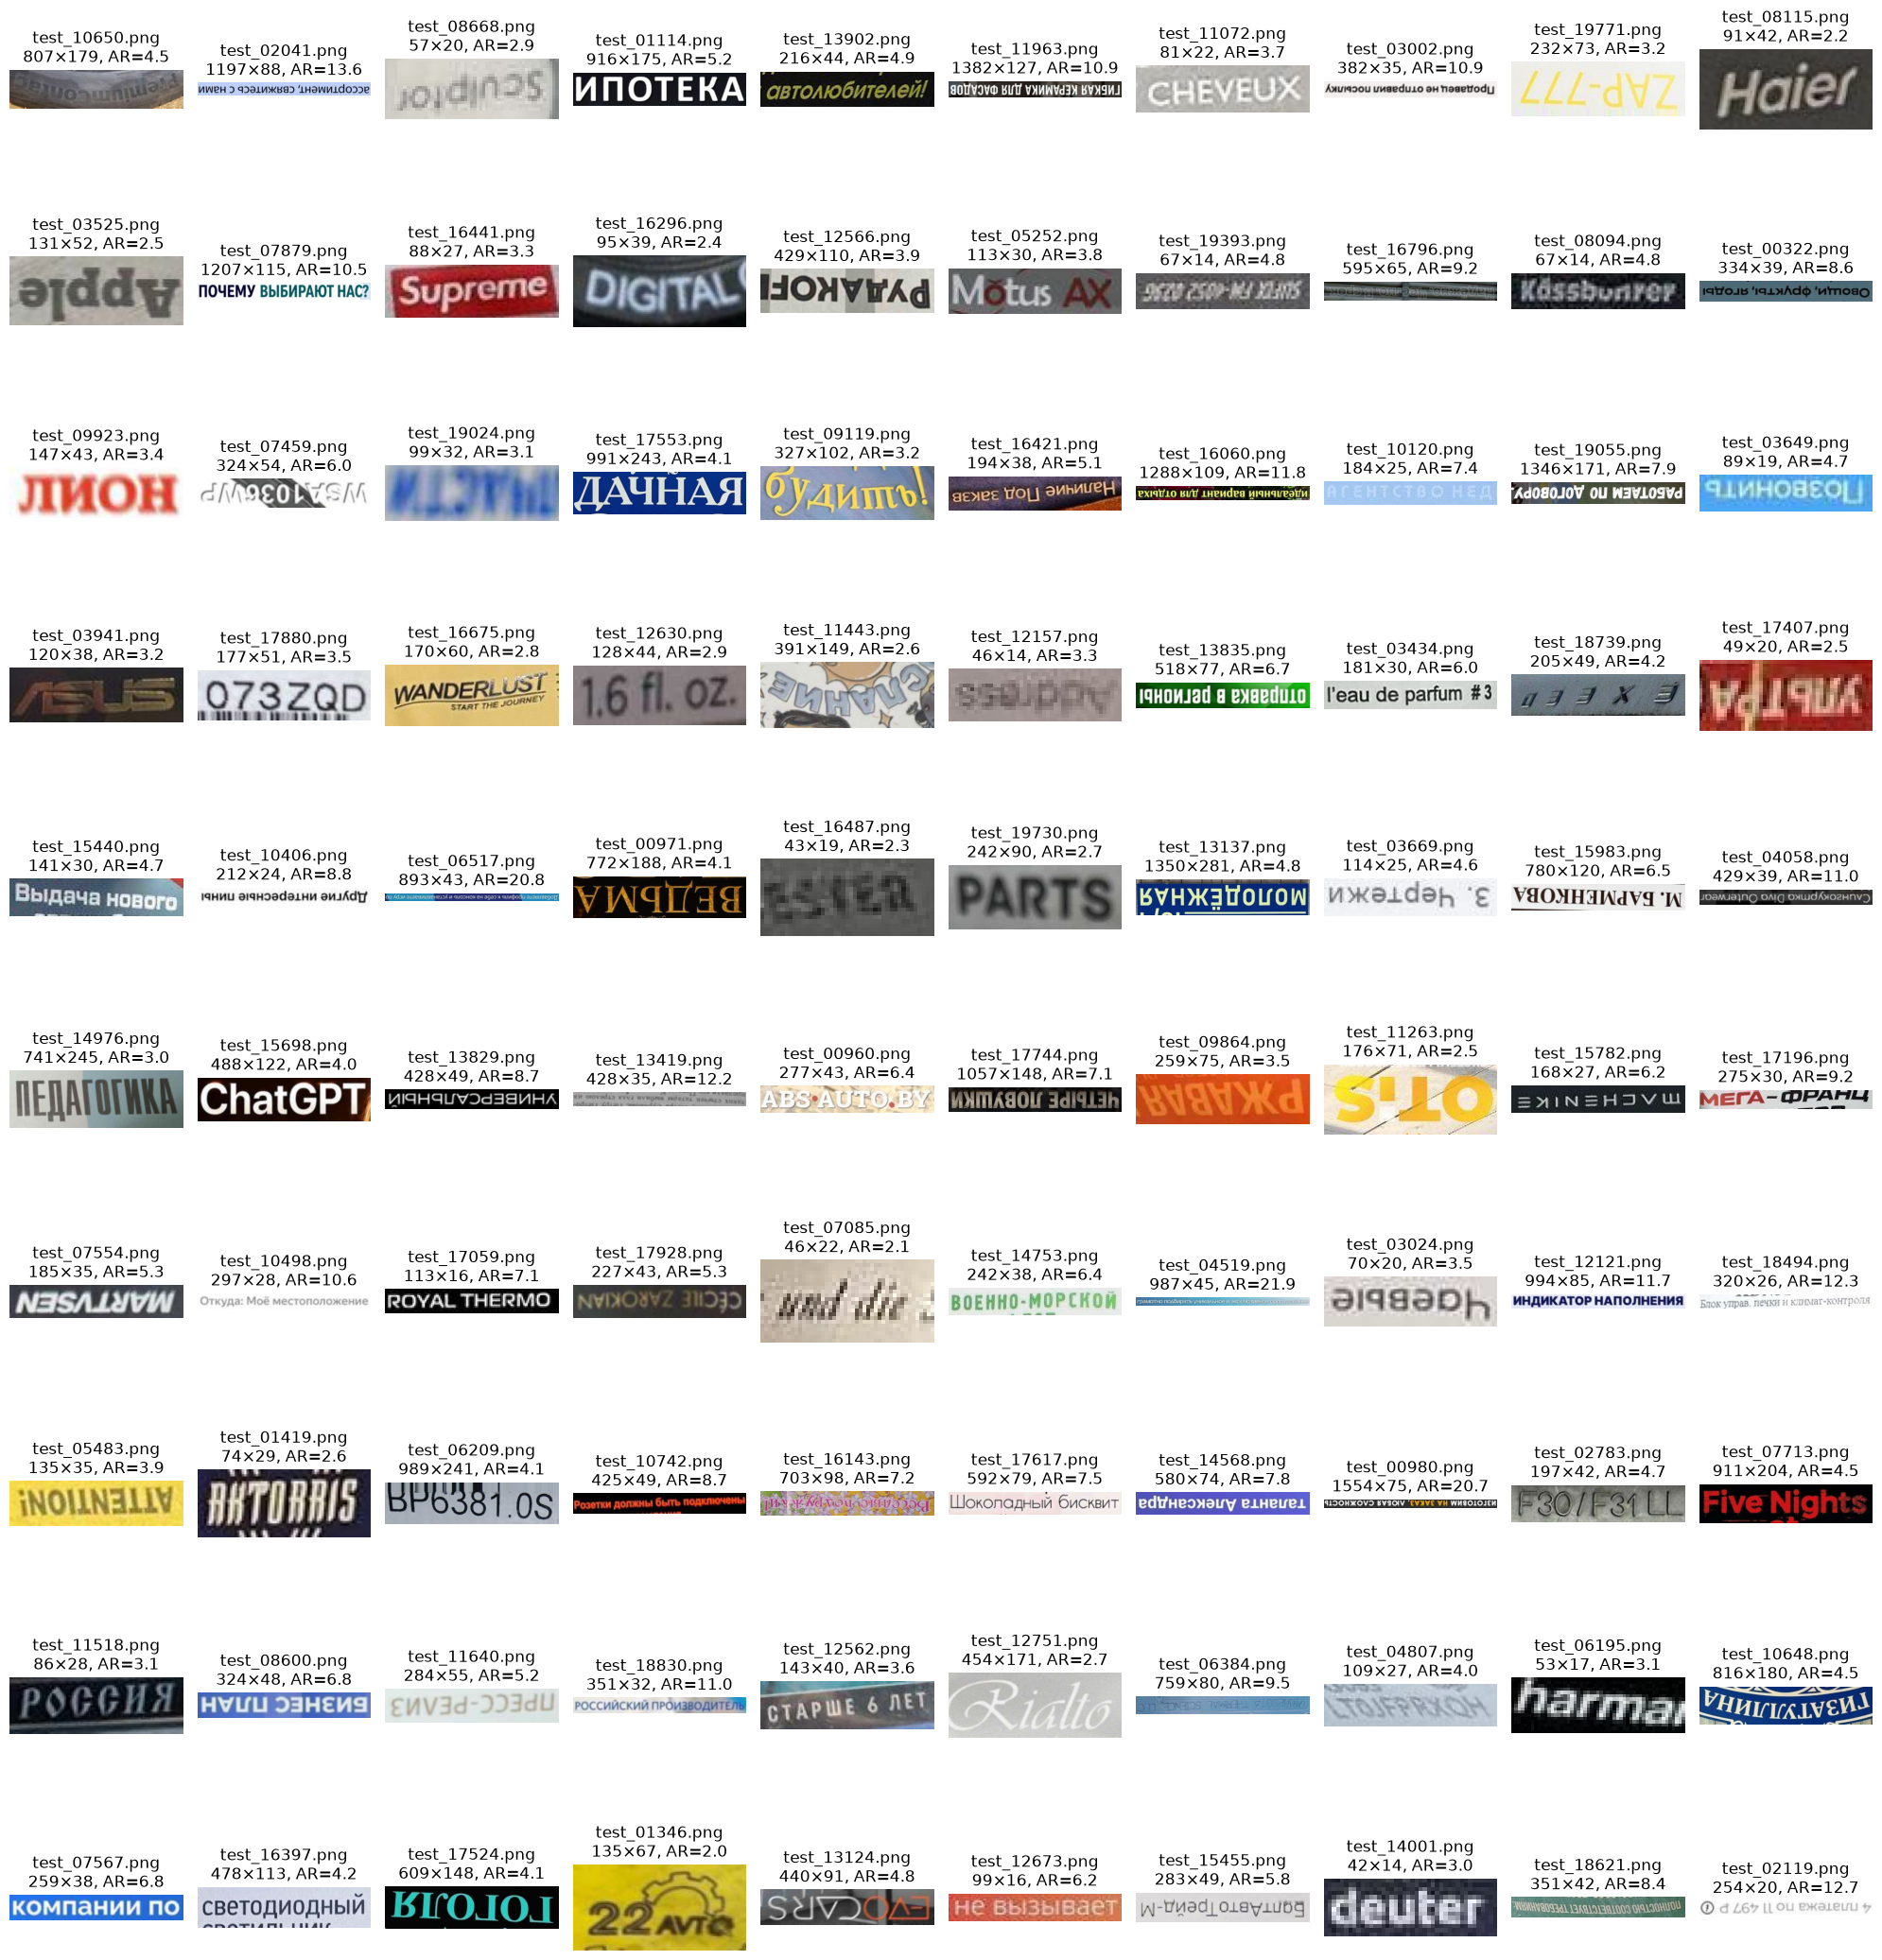

In [19]:
show_images(
    df.sample(100, random_state=42),
    cols=10,
    figsize=(20, 22)
)

In [20]:
bins = [
    0, 1.5, 2, 3, 4, 5, 7.5, 10, 15, 20, 30, np.inf
]

ar_dist = pd.cut(
    df["aspect_ratio"],
    bins=bins,
    right=False
).value_counts(sort=False)

pd.DataFrame({
    "count": ar_dist,
    "percent": ar_dist / len(df) * 100
})

,count,percent
aspect_ratio,,
"[0.0, 1.5)",65,0.325
"[1.5, 2.0)",364,1.820
"[2.0, 3.0)",2567,12.835
"[3.0, 4.0)",3889,19.445
"[4.0, 5.0)",3364,16.820
"[5.0, 7.5)",4720,23.600
"[7.5, 10.0)",2209,11.045
"[10.0, 15.0)",1943,9.715
"[15.0, 20.0)",553,2.765


In [21]:
df.to_csv(PROJECT_ROOT / "data" / "test_metadata.csv", index=False)